# Lab 4 — Statistics Intuition

Explore mean, median, standard deviation, percentiles, distribution, skewness, outliers, correlation, and a simple hypothesis test using the Wine Quality dataset.

Mean: 10.442111402741325
Median: 10.2
Standard Deviation: 1.0821956098764445

Percentiles:
0.25     9.5
0.50    10.2
0.75    11.1
Name: alcohol, dtype: float64

Mean-Median Gap: 0.24211140274132603
The mean is higher than the median, suggesting a right-skewed distribution.

Skewness: 0.8633132317223615


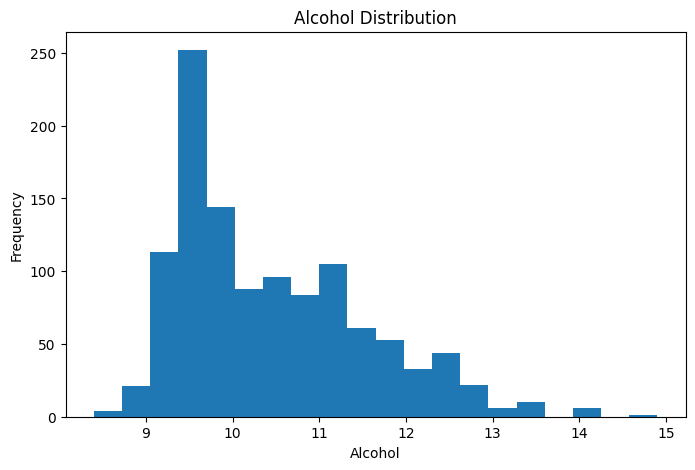


Lower Bound: 7.1000000000000005
Upper Bound: 13.5
Number of Outliers: 12

Correlation Matrix:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954



Alcohol and Quality Correlation:
0.48486621180851264

Strongest Correlation Pair:
('fixed acidity', 'pH')
-0.6851625988235482

Mean Alcohol - Quality <= 5: 9.922509578544062
Mean Alcohol - Quality >= 6: 10.878878153515833

T-Statistic: -17.067079800674428
P-Value: 3.7124677991679934e-58

Interpretation:
Higher-quality wines have higher mean alcohol content.
The p-value indicates strong evidence that the two groups have different mean alcohol levels.
Correlation does not imply causation.


In [ ]:
# ============================================================
# 04 - Statistics Intuition
# Wine Quality Dataset
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

df = pd.read_csv("../week2-data-processing/data/WineQT.csv")

# ============================================================
# 1. Descriptive Statistics
# ============================================================

alcohol = df["alcohol"]

print("Mean:", alcohol.mean())
print("Median:", alcohol.median())
print("Standard Deviation:", alcohol.std())

print("\nPercentiles:")
print(alcohol.quantile([0.25, 0.50, 0.75]))

gap = alcohol.mean() - alcohol.median()

print("\nMean-Median Gap:", gap)

if gap > 0:
    print("The mean is higher than the median, suggesting a right-skewed distribution.")
elif gap < 0:
    print("The mean is lower than the median, suggesting a left-skewed distribution.")
else:
    print("The mean and median are equal, suggesting a relatively symmetric distribution.")

# ============================================================
# 2. Distribution and Skewness
# ============================================================

print("\nSkewness:", alcohol.skew())

plt.figure(figsize=(8, 5))
plt.hist(alcohol, bins=20)
plt.title("Alcohol Distribution")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()

# ============================================================
# 3. Outlier Detection
# ============================================================

q1 = alcohol.quantile(0.25)
q3 = alcohol.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (alcohol < lower_bound) |
    (alcohol > upper_bound)
]

print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

# ============================================================
# 4. Correlation
# ============================================================

correlation = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
display(correlation)

print("\nAlcohol and Quality Correlation:")
print(correlation.loc["alcohol", "quality"])

corr = correlation.abs().where(correlation.abs() < 1)
strongest = corr.stack().idxmax()

print("\nStrongest Correlation Pair:")
print(strongest)
print(correlation.loc[strongest])

# ============================================================
# 5. Hypothesis Test
# ============================================================

group1 = df[df["quality"] <= 5]["alcohol"]
group2 = df[df["quality"] >= 6]["alcohol"]

print("\nMean Alcohol - Quality <= 5:", group1.mean())
print("Mean Alcohol - Quality >= 6:", group2.mean())

t_stat, p_value = ttest_ind(
    group1,
    group2,
    equal_var=False
)

print("\nT-Statistic:", t_stat)
print("P-Value:", p_value)

# ============================================================
# 6. Interpretation
# ============================================================

print("\nInterpretation:")
print("Higher-quality wines have higher mean alcohol content.")
print("The p-value indicates strong evidence that the two groups have different mean alcohol levels.")
print("Correlation does not imply causation.")

## Conclusion

The alcohol variable has a mean of approximately 10.44 and a median of 10.2, with moderate right skewness. Outliers were identified using the IQR method. Alcohol and wine quality show a positive correlation, while the hypothesis test indicates a statistically significant difference in mean alcohol content between the lower- and higher-quality groups.